In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.insert(0, r"../main_code/3d")
for _mod in ['generate_data', 'mesh', 'adaptive_int', 'visual', 'matrix_assemble', 'inverse_solver', 'mea_3d', 'net_3d', 'source_eval', 'error_general_3d', 'main', 'bound_detect', 'q_filter']:
    sys.modules.pop(_mod, None)
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_3d,net_3d,source_eval,error_general_3d,main
CUDA_LAUNCH_BLOCKING=3

def f_y(x, x_min,x_max,y_min,y_max,z_min,z_max,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1) 
    
    # Apply the piecewise function
    f_y_values = np.where(r_y < r, r - r_y, 0.0)
    return f_y_values

def ana_S(x,x_min,x_max,y_min,y_max,z_min,z_max,a,b,r): # x is the data array; a and b are center coordinates
    return f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,a,r)-f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,b,r)

    

cuda:3


In [2]:
import copy
Nx,Ny,Nz=1,1,1
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81]
tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max=0,1,0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max=-0.5,1.5,-0.5,1.5,-0.5,1.5 # On boundary Gamma
num_batches_gauss=1
b_n=10
points_b=mea_3d.generate_cube_surface(b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.15
center_1=np.array([0.3,0.5,0.3])
center_2=np.array([0.5,0.5,0.8])
center_true=np.array([[0.3,0.5,0.3],[0.5,0.5,0.8]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
num_batches_gauss=4
num_batches_appr=10
num_batches_mea=1
cupy_device = device.index if device.type == "cuda" else 0

In [3]:
F_81_5_15=np.load("./noise=5%/F_81_5%.npy")

In [4]:
M=7200
af="Tanh"   # Initial activation setting
R_m=10
models0 = net_3d.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=[], r_max=[],b1_min=[],b1_max=[],b2_min=[],b2_max=[],b3_min=[],b3_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af=af,device=device).to(device)

Plotting 64 cells. Levels: 0 to 0


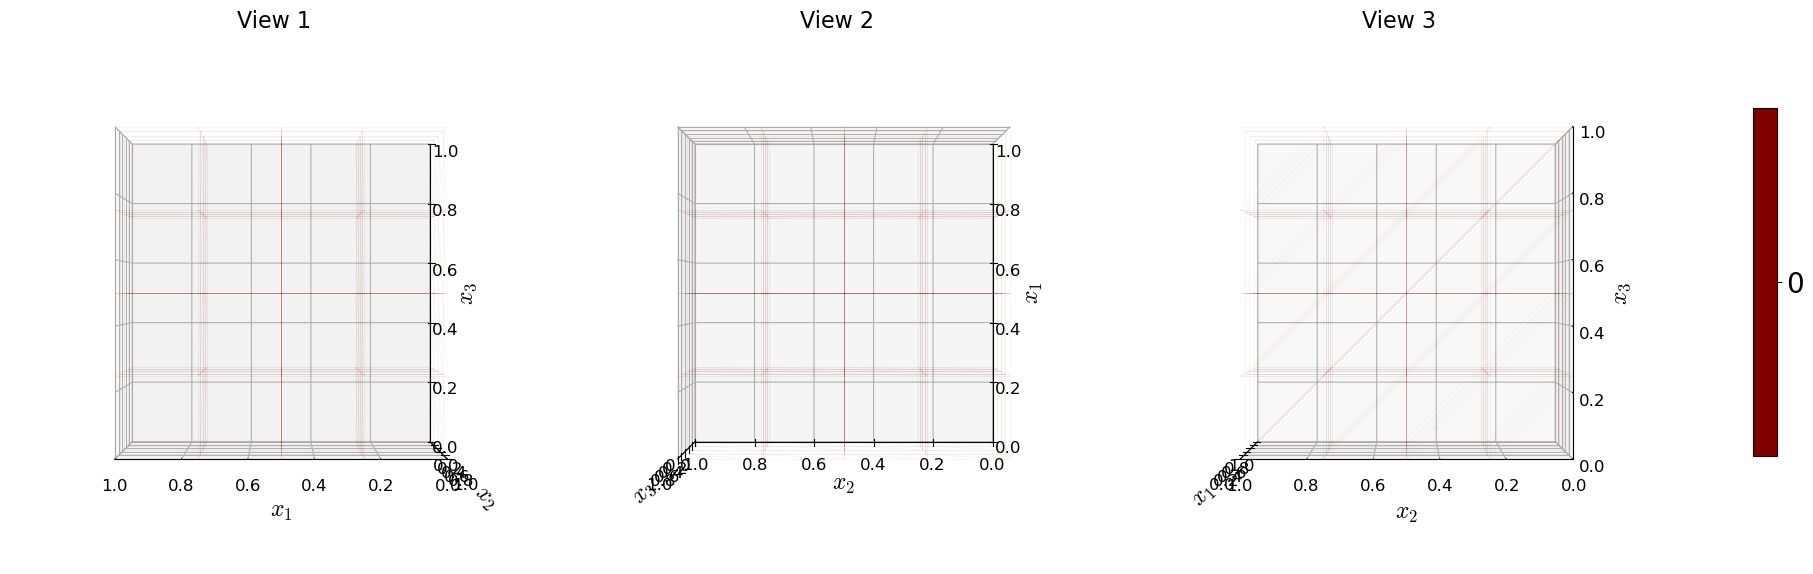

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1241: RuntimeWarning: invalid value encountered in divide
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1278: RuntimeWarning: divide by zero encountered in scalar divide
  a = -1.5 / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1279: RuntimeWarning: divide by zero encountered in scalar divide
  b = 2. / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1280: RuntimeWarning: divide by zero encountered in scalar divide
  c = -0.5 / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1288: RuntimeWarning: invalid value encountered in scalar add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(

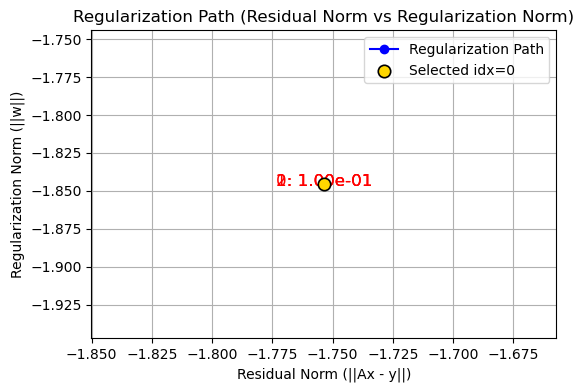

L-curve corner index: 0
Selected lambda by curvature: 1.000000e-01
  idx=0, lambda=1.000000e-01, curvature=0.000000e+00
  idx=1, lambda=1.000000e-01, curvature=0.000000e+00
  idx=2, lambda=1.000000e-01, curvature=0.000000e+00
Top curvature candidates:
  rank=1, idx=1, lambda=1.000000e-01, curvature=0.000000e+00
Training error at iteration 0 :
S_l_inf= 6.973073021880636 S_L_2= 0.0061378993347561426 S_l_2= 0.6593749515281283
Generalization error at iteration 0 :
S_l_inf= 13.433634054244042 S_L_2= 0.005494345320519097 S_l_2= 0.6992039756570628


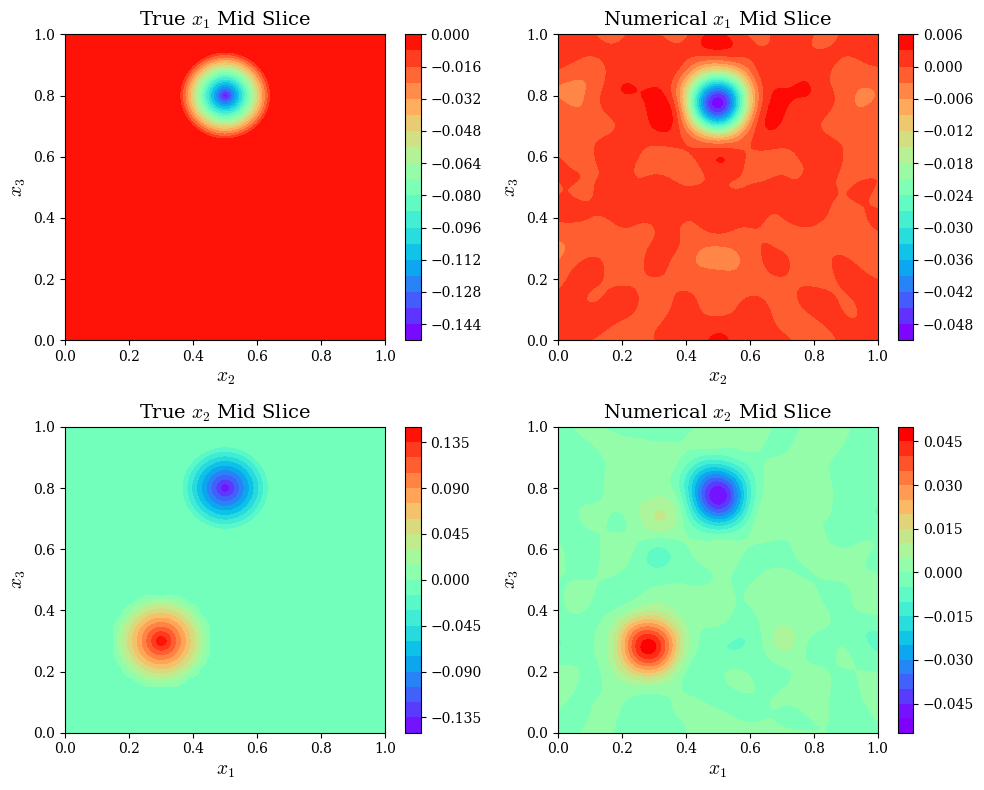

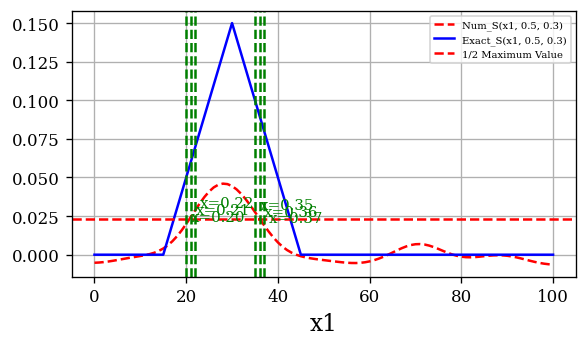

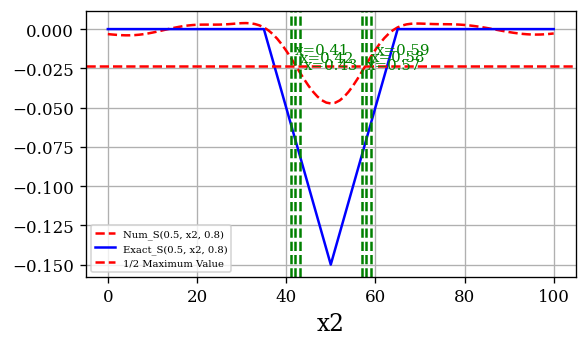

Adaptive mesh refinement at iteration 0 ...
Current number of cells: 512
Plotting 512 cells. Levels: 1 to 1


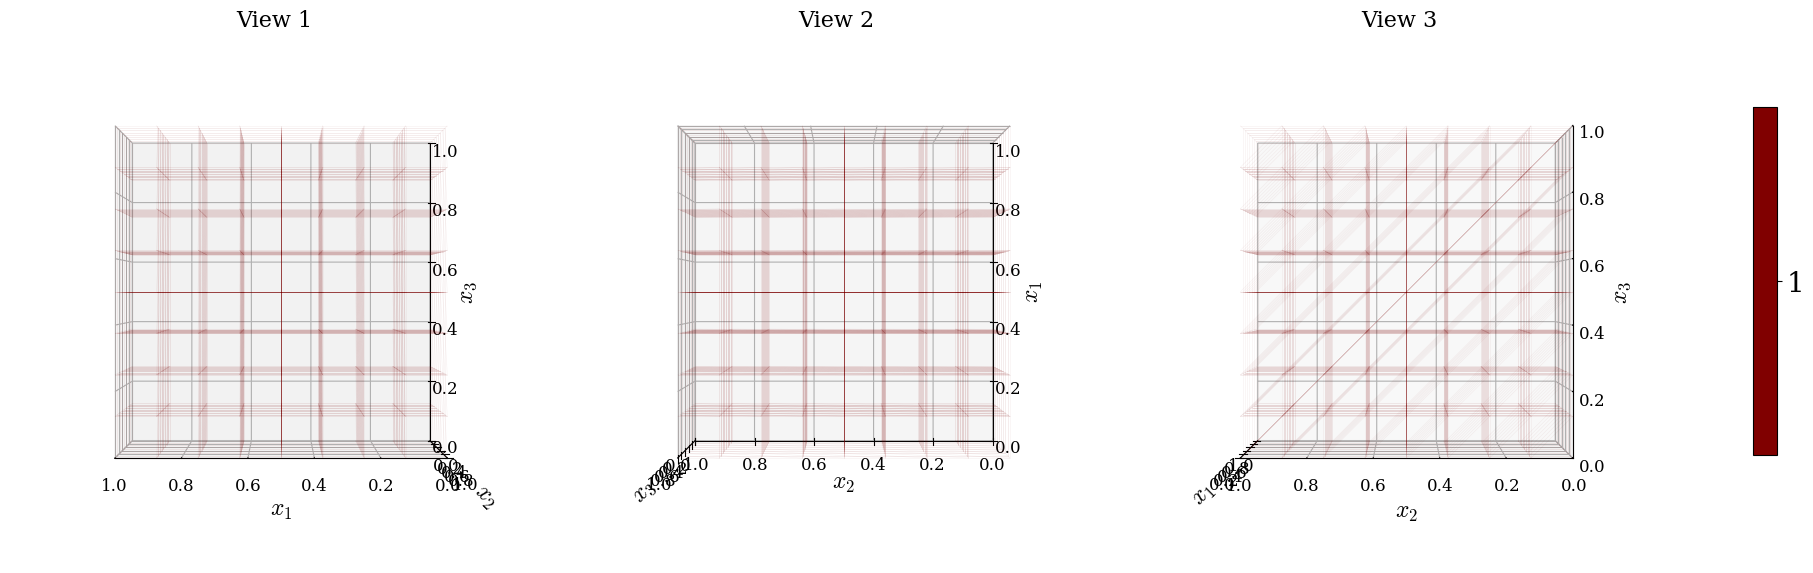

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1241: RuntimeWarning: invalid value encountered in divide
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1278: RuntimeWarning: divide by zero encountered in scalar divide
  a = -1.5 / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1279: RuntimeWarning: divide by zero encountered in scalar divide
  b = 2. / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1280: RuntimeWarning: divide by zero encountered in scalar divide
  c = -0.5 / ax_dx
/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1288: RuntimeWarning: invalid value encountered in scalar add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(

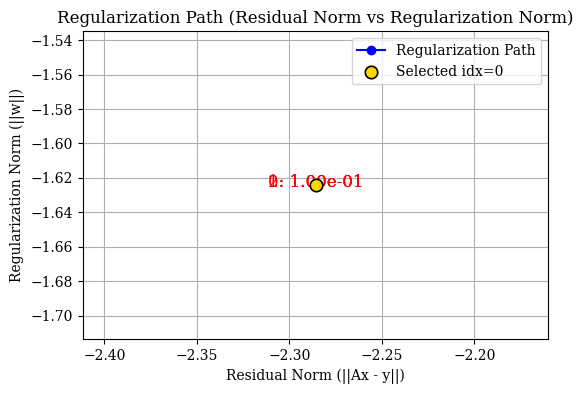

L-curve corner index: 0
Selected lambda by curvature: 1.000000e-01
  idx=0, lambda=1.000000e-01, curvature=0.000000e+00
  idx=1, lambda=1.000000e-01, curvature=0.000000e+00
  idx=2, lambda=1.000000e-01, curvature=0.000000e+00
Top curvature candidates:
  rank=1, idx=1, lambda=1.000000e-01, curvature=0.000000e+00
Training error at iteration 1 :
S_l_inf= 2.354324364997326 S_L_2= 0.001447482409368643 S_l_2= 0.18112258160255018
Generalization error at iteration 1 :
S_l_inf= 4.7290292039779365 S_L_2= 0.0014330148665323602 S_l_2= 0.1823638001261335


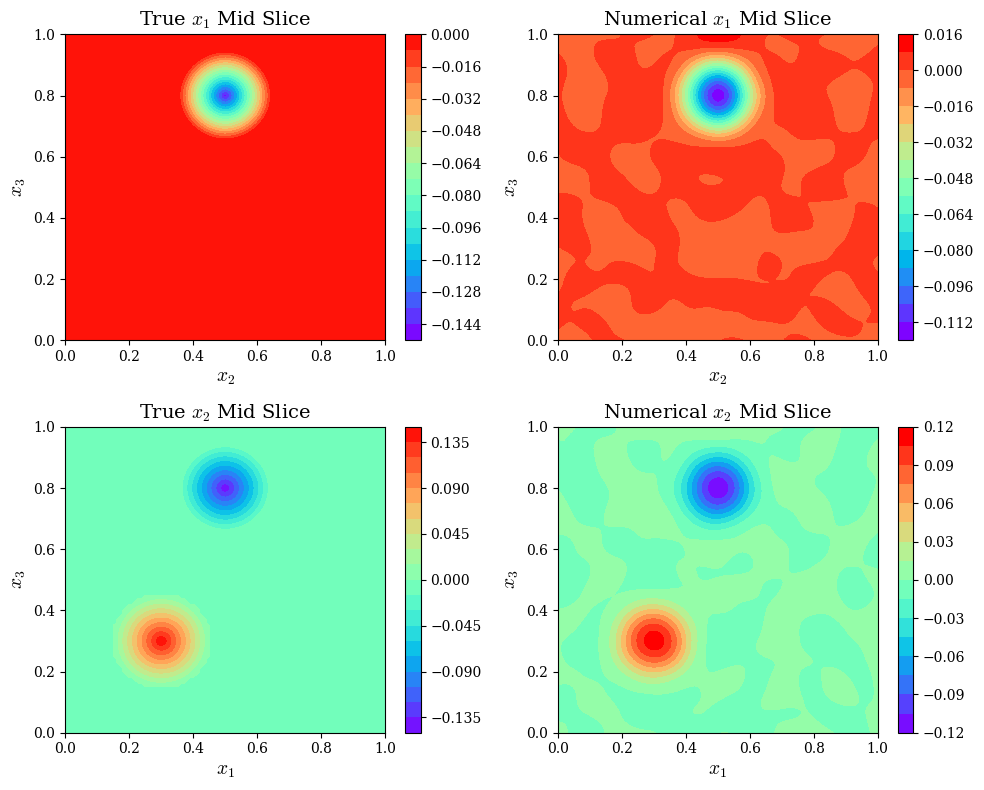

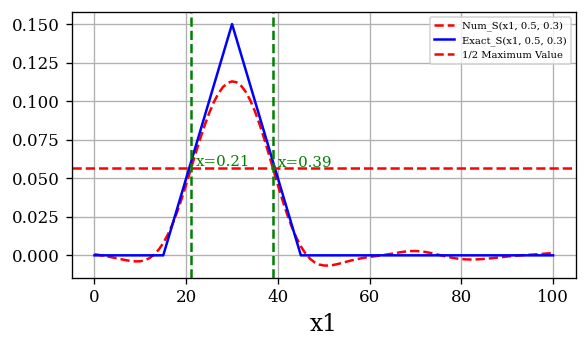

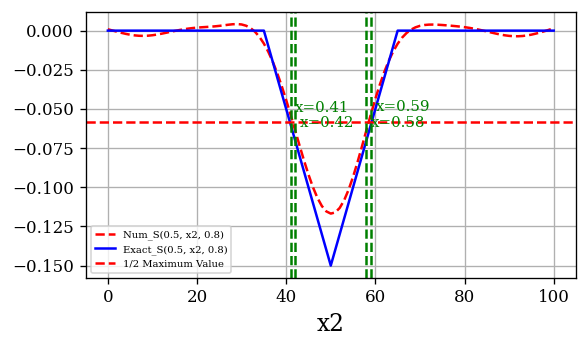

Adaptive mesh refinement at iteration 1 ...
Current number of cells: 799
Plotting 799 cells. Levels: 1 to 2


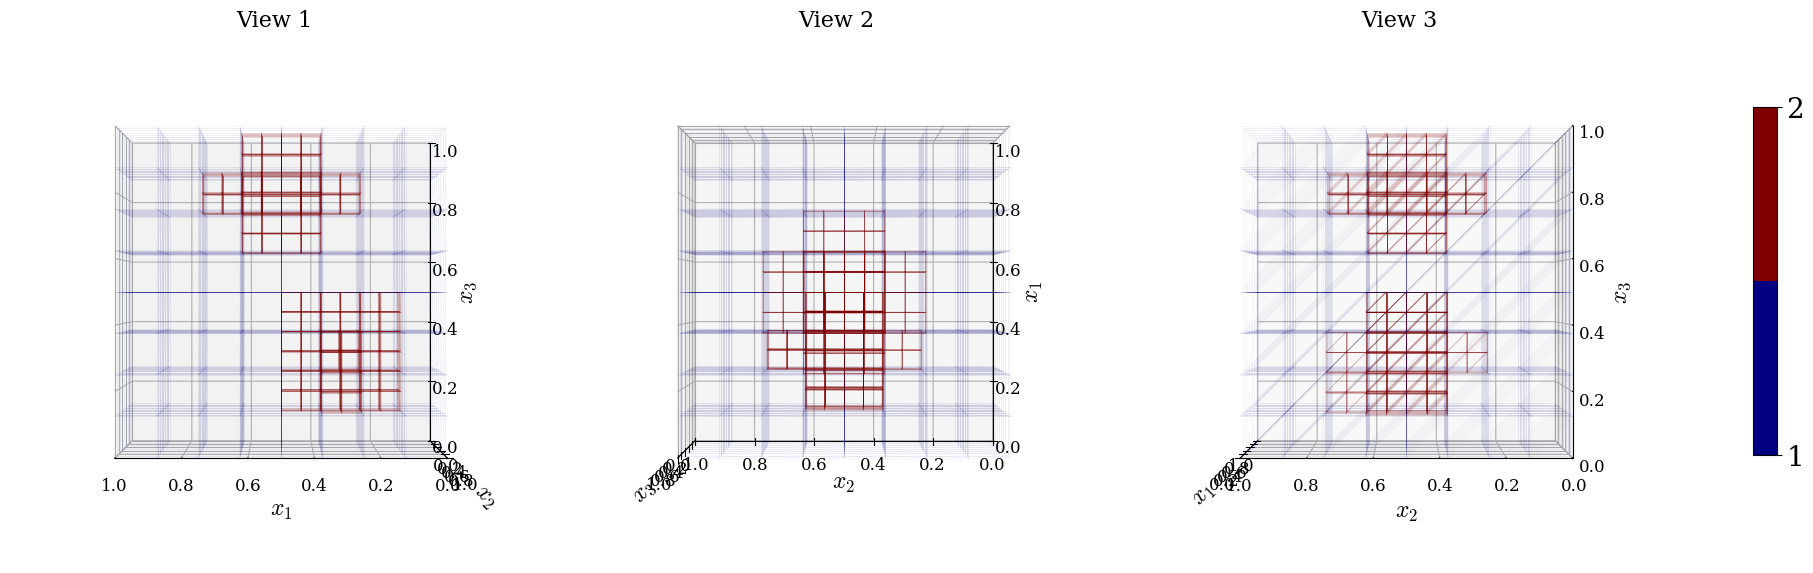

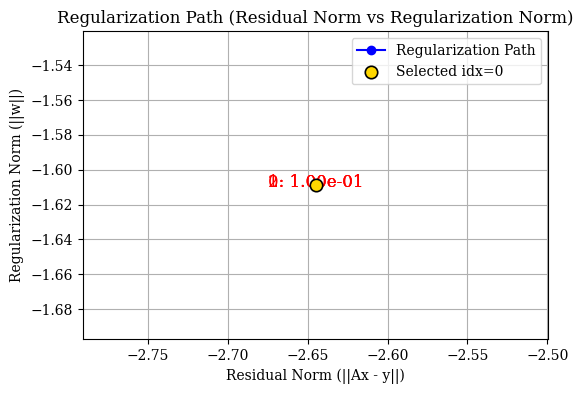

L-curve corner index: 0
Selected lambda by curvature: 1.000000e-01
  idx=0, lambda=1.000000e-01, curvature=0.000000e+00
  idx=1, lambda=1.000000e-01, curvature=0.000000e+00
  idx=2, lambda=1.000000e-01, curvature=0.000000e+00
Top curvature candidates:
  rank=1, idx=1, lambda=1.000000e-01, curvature=0.000000e+00
Training error at iteration 2 :
S_l_inf= 0.9616421149355191 S_L_2= 0.0017950836609685686 S_l_2= 0.0993621121520844
Generalization error at iteration 2 :
S_l_inf= 3.405543455888547 S_L_2= 0.0009327773062464353 S_l_2= 0.11870415179302458


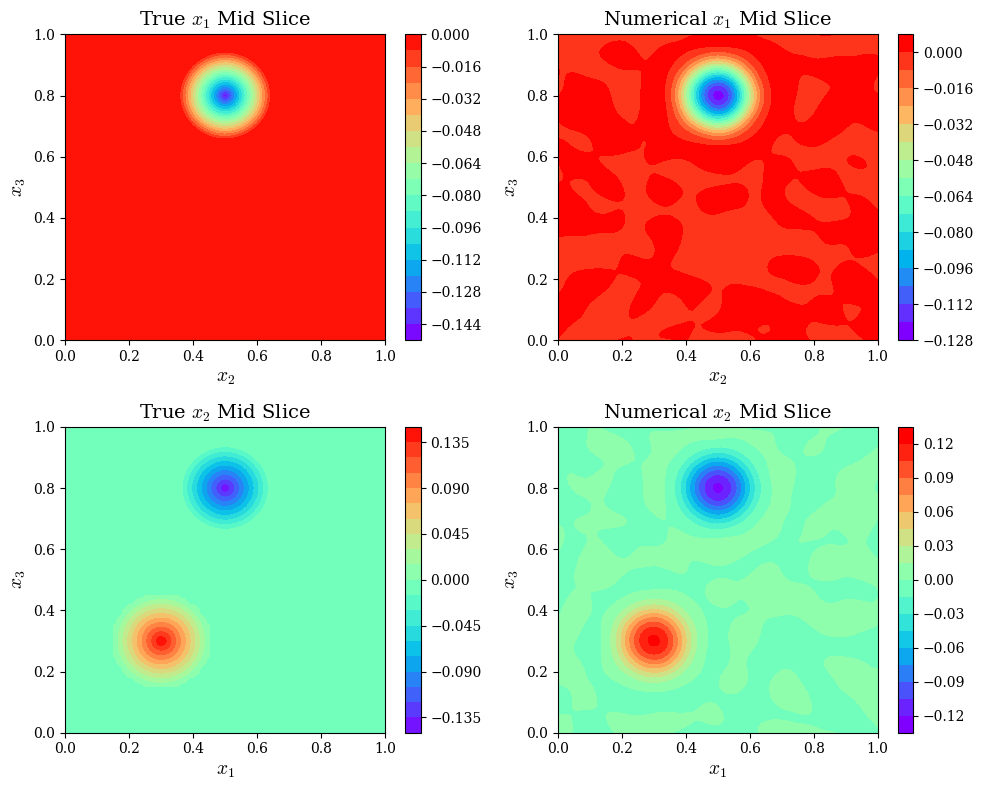

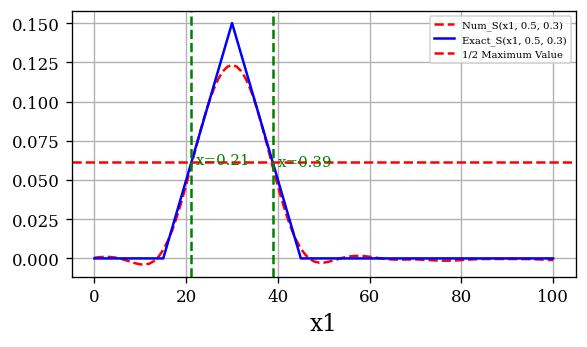

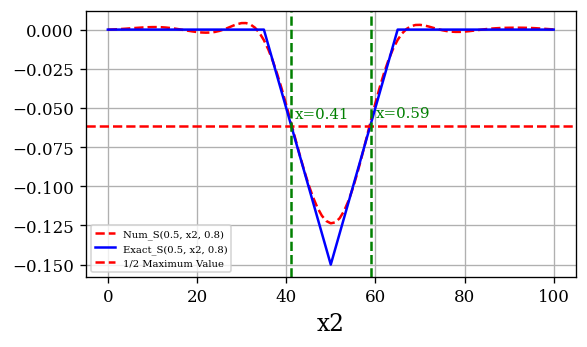

Adaptive mesh refinement at iteration 2 ...
Current number of cells: 1506


In [5]:
Ix,Iy,Iz=4,4,4  # Number of grid cells in the x direction
nx,ny,nz=3,3,3  # Gauss points per cell in the x direction
cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
delta=10**(-3)
lamb_regu=np.logspace(-1,-1,3)

Qx,Qy,Qz=50,50,50
iter_int=3
max_level=4
current_maxiter=1
refine_threshold_S = 1/100
refine_threshold_grad = 1/300
ratio1=[0.3,0.5,0.3]
ratio2=[0.5,0.5,0.8]
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_basis=main.ada_int(iter_int,delta,cells,nx,models0,M,"Tanh",kk,F_81_5_15,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,Qz,ratio1,ratio2,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)